# DINOv2: Self-Supervised Visual Features for Few-Shot CIFAR-10 Classification

This notebook evaluates **DINOv2** (Oquab et al., TMLR 2024) on CIFAR-10 using three few-shot protocols: **k-NN**, **nearest-prototype** (matching the ProtoNet-style protocol already described in Section 4.3 of the report), and **linear probing**.

**Important difference from CLIP:** DINOv2 is trained with *no text supervision at all* (Section 2.1.3 of the report) — it has no text tower and therefore **no zero-shot classification is possible**. Every result below requires at least K=1 labeled example per class. This is expected and is itself a useful point of comparison against CLIP's zero-shot capability.

---

In [1]:
# ── Install required packages ──────────────────────────────────────────────
!pip install -q transformers
print("\u2705 Installed.")

✅ Installed.


In [2]:
# ── Core imports ───────────────────────────────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset

from transformers import AutoImageProcessor, AutoModel

import warnings
warnings.filterwarnings('ignore')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE.upper()}")

Running on: CPU


## 1 — Load DINOv2 and CIFAR-10

In [3]:
# ── Load DINOv2 (ViT-S/14, small variant for speed) ──────────────────────────
# Swap to 'facebook/dinov2-base' for the larger variant if you have time/compute to spare
MODEL_NAME = "facebook/dinov2-small"

print(f"Loading {MODEL_NAME}...")
dino_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
dino_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
dino_model.eval()

EMBED_DIM = dino_model.config.hidden_size
print(f"\u2705 DINOv2 loaded! Embedding dim: {EMBED_DIM}")

Loading facebook/dinov2-small...


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

✅ DINOv2 loaded! Embedding dim: 384


In [4]:
# ── Load CIFAR-10 (same setup as the other notebooks, for comparability) ────
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
raw_cifar10 = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

indices_per_class = {c: [] for c in range(10)}
for idx, (_, label) in enumerate(raw_cifar10):
    if len(indices_per_class[label]) < 50:
        indices_per_class[label].append(idx)
    if all(len(v) == 50 for v in indices_per_class.values()):
        break
test_indices = [idx for idxs in indices_per_class.values() for idx in idxs]
test_subset = Subset(raw_cifar10, test_indices)
print(f"Test set: {len(test_subset)} images (50 per class)")

100%|██████████| 170M/170M [15:10<00:00, 187kB/s]


Test set: 500 images (50 per class)


In [5]:
# ── DINOv2 feature extraction (CLS token, L2-normalized) ────────────────────
def extract_dino_features(dataset):
    feats, labels = [], []
    with torch.no_grad():
        for img_tensor, label in dataset:
            pil_img = transforms.ToPILImage()(img_tensor)
            inputs = dino_processor(images=pil_img, return_tensors="pt").to(DEVICE)
            out = dino_model(**inputs)
            cls_feat = out.last_hidden_state[:, 0, :]           # CLS token
            cls_feat = F.normalize(cls_feat, dim=-1)
            feats.append(cls_feat.cpu())
            labels.append(label)
    return torch.cat(feats, dim=0).float(), torch.tensor(labels)

def build_shot_subset(k):
    indices = []
    seen = {c: 0 for c in range(10)}
    for idx, (_, label) in enumerate(cifar_train):
        if seen[label] < k:
            indices.append(idx)
            seen[label] += 1
        if all(v == k for v in seen.values()):
            break
    return Subset(cifar_train, indices)

print("Extracting DINOv2 features for test set (500 images)...")
F_test, y_test = extract_dino_features(test_subset)
print(f"F_test shape: {F_test.shape}")

Extracting DINOv2 features for test set (500 images)...
F_test shape: torch.Size([500, 384])


---

## 2 — Three few-shot evaluation protocols

1. **Nearest-prototype** — class prototype = mean of K embeddings per class; classify by nearest prototype (matches the ProtoNet protocol from Section 4.3).
2. **k-NN** — classify by majority vote over the nearest labeled neighbours in the K-shot support set.
3. **Linear probe** — train a linear classifier on top of frozen DINOv2 features.

In [6]:
# ── Protocol 1: Nearest-prototype classification ────────────────────────────
def eval_prototype(F_train, y_train, F_query, y_query):
    prototypes = torch.stack([F_train[y_train == c].mean(dim=0) for c in range(10)])
    prototypes = F.normalize(prototypes, dim=-1)
    sims = F_query @ prototypes.T
    preds = sims.argmax(dim=1)
    return (preds == y_query).float().mean().item() * 100

In [7]:
# ── Protocol 2: k-NN classification ──────────────────────────────────────────
def eval_knn(F_train, y_train, F_query, y_query, k_neighbors=5):
    k_neighbors = min(k_neighbors, F_train.shape[0])
    sims = F_query @ F_train.T                       # [n_query, n_train]
    topk = sims.topk(k_neighbors, dim=1).indices      # [n_query, k]
    topk_labels = y_train[topk]                       # [n_query, k]
    preds = torch.mode(topk_labels, dim=1).values
    return (preds == y_query).float().mean().item() * 100

In [8]:
# ── Protocol 3: Linear probe ─────────────────────────────────────────────────
class LinearProbe(torch.nn.Module):
    def __init__(self, input_dim, num_classes=10):
        super().__init__()
        self.fc = torch.nn.Linear(input_dim, num_classes)
    def forward(self, x):
        return self.fc(x)

def eval_linear_probe(F_train, y_train, F_query, y_query, epochs=20, lr=1e-3, batch_size=64):
    probe = LinearProbe(F_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(probe.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(F_train.to(DEVICE), y_train.to(DEVICE)),
        batch_size=batch_size, shuffle=True)
    for epoch in range(epochs):
        probe.train()
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(probe(bx), by)
            loss.backward()
            optimizer.step()
    probe.eval()
    with torch.no_grad():
        preds = probe(F_query.to(DEVICE)).argmax(dim=1).cpu()
    return (preds == y_query).float().mean().item() * 100

In [9]:
# ── Run the K-shot sweep across all three protocols ──────────────────────────
K_VALUES = [1, 5, 10, 50, 100]
results = {'prototype': {}, 'knn': {}, 'linear_probe': {}}

print(f"{'K':>5} {'Prototype':>11} {'k-NN':>8} {'Linear Probe':>14}")
print("-" * 44)

for k in K_VALUES:
    shot_subset = build_shot_subset(k)
    F_train, y_train = extract_dino_features(shot_subset)

    acc_proto = eval_prototype(F_train, y_train, F_test, y_test)
    acc_knn   = eval_knn(F_train, y_train, F_test, y_test, k_neighbors=min(5, k))
    acc_lp    = eval_linear_probe(F_train, y_train, F_test, y_test)

    results['prototype'][k]    = acc_proto
    results['knn'][k]          = acc_knn
    results['linear_probe'][k] = acc_lp

    print(f"{k:>5} {acc_proto:>10.1f}% {acc_knn:>7.1f}% {acc_lp:>13.1f}%")

print("-" * 44)

    K   Prototype     k-NN   Linear Probe
--------------------------------------------
    1       73.2%    73.2%          61.8%
    5       85.4%    81.8%          71.8%
   10       88.0%    85.2%          76.2%
   50       94.4%    92.0%          92.6%
  100       94.2%    94.2%          93.4%
--------------------------------------------


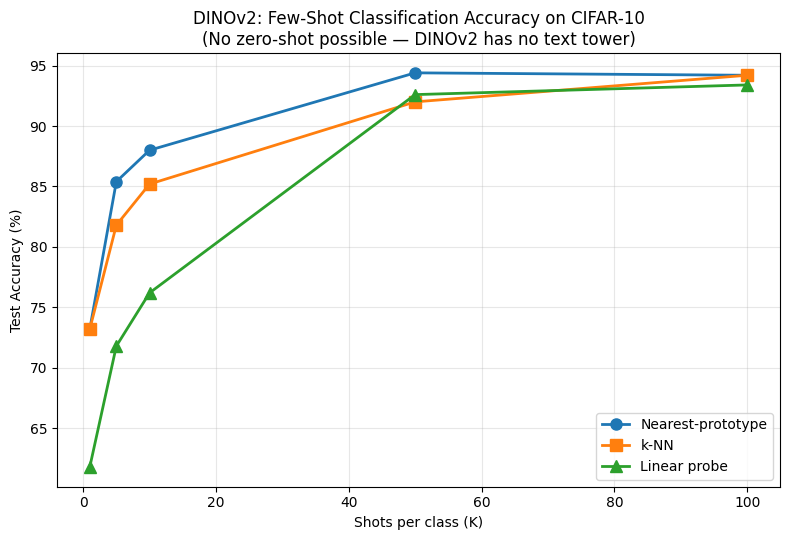

In [10]:
# ── Plot the few-shot learning curves ────────────────────────────────────────
plt.figure(figsize=(8, 5.5))
plt.plot(K_VALUES, [results['prototype'][k] for k in K_VALUES], 'o-', linewidth=2, markersize=8, label='Nearest-prototype')
plt.plot(K_VALUES, [results['knn'][k] for k in K_VALUES], 's-', linewidth=2, markersize=8, label='k-NN')
plt.plot(K_VALUES, [results['linear_probe'][k] for k in K_VALUES], '^-', linewidth=2, markersize=8, label='Linear probe')
plt.xlabel('Shots per class (K)')
plt.ylabel('Test Accuracy (%)')
plt.title('DINOv2: Few-Shot Classification Accuracy on CIFAR-10\n(No zero-shot possible \u2014 DINOv2 has no text tower)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dinov2_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 3 — Summary (for the report)

Paste the printed table above into Chapter 6 alongside the CLIP zero-shot/linear-probe and Tip-Adapter results for a direct text-supervised vs. vision-only comparison. Note in your writeup that DINOv2's dense per-patch features (not used here) are exactly what the Future Work section proposes for few-shot segmentation — this notebook only evaluates the pooled CLS-token classification setting.